# HDFS (Hadoop Distributed File System)

HDFS (Hadoop Distributed File System) is the primary storage system used by Hadoop to store and manage large volumes of data across a distributed cluster. It is designed for high fault tolerance, scalability, and the ability to handle massive datasets efficiently.

## Key Features of HDFS

1. **Distributed Architecture**
   - Data is divided into blocks and stored across multiple nodes in a cluster.
   - This ensures parallel data access and high throughput.

2. **Fault Tolerance**
   - Data blocks are replicated across different nodes (default replication factor is 3).
   - If a node fails, data can still be retrieved from replicas on other nodes.

3. **Scalability**
   - HDFS can scale horizontally by adding more nodes to the cluster to handle growing datasets.

4. **Write Once, Read Many**
   - Data written to HDFS is immutable; it can only be appended but not modified.
   - Optimized for workloads like data analysis where frequent reads are required.

5. **High Throughput**
   - Optimized for batch processing rather than low-latency access, making it suitable for analytics.

6. **Data Locality**
   - HDFS moves computation (MapReduce or other frameworks) to the data rather than moving data to computation, reducing network bandwidth usage.

7. **Compatibility**
   - Works seamlessly with Hadoop's ecosystem, such as Hive, Spark, and Pig.

## Architecture of HDFS

1. **NameNode (Master)**
   - Manages the file system metadata (e.g., file names, directories, permissions).
   - Does not store actual data, only the locations of data blocks.
   - High availability is achieved with secondary NameNodes or active-passive setups.

2. **DataNode (Worker)**
   - Stores the actual data blocks.
   - Responsible for serving read and write requests from clients.
   - Periodically sends heartbeats and block reports to the NameNode.

3. **Secondary NameNode**
   - Assists the NameNode in managing metadata by taking periodic snapshots of the file system namespace and edit logs.
   - Not a backup for the NameNode.

4. **Block Storage**
   - Files are split into fixed-size blocks (default size is 128 MB or 256 MB).
   - Blocks are distributed and replicated across DataNodes.
  
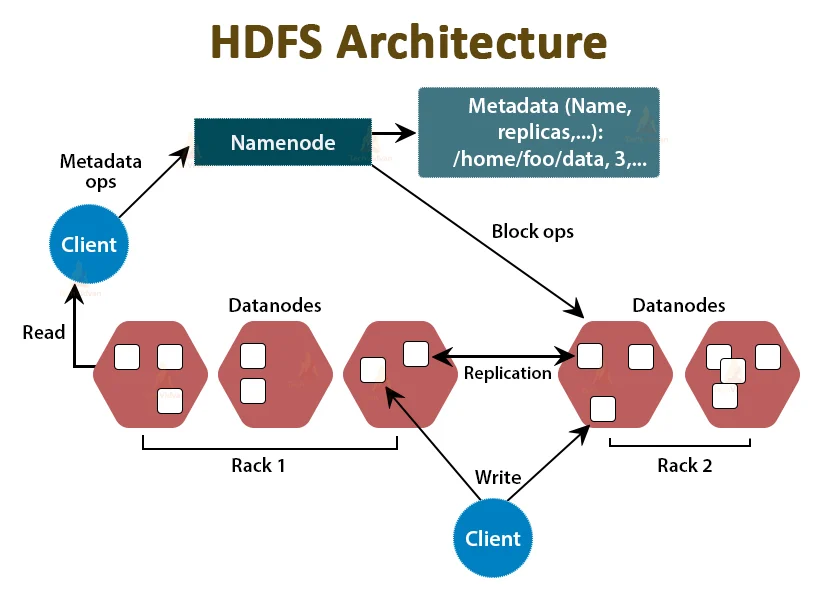

## Workflow

### 1. File Write Operation
A file is divided into fixed-size blocks (default: 128 MB or 256 MB). Blocks are stored on different DataNodes for fault tolerance, adhering to the replication factor (e.g., 3 replicas). The NameNode determines the DataNodes where each block should be stored.

**Steps:**
1. The client sends a write request to the NameNode.
2. The NameNode assigns DataNodes for each block.
3. The client writes the blocks to the assigned DataNodes.
4. DataNodes replicate the blocks to other DataNodes.

### 2. File Read Operation
The client requests a file from HDFS, and the NameNode provides the locations of the file's blocks. The client directly retrieves the blocks from the corresponding DataNodes.

**Steps:**
1. Client sends a read request to the NameNode.
2. The NameNode provides block locations.
3. The client reads blocks directly from the DataNodes.

## Advantages of HDFS
- **Cost-Effective**: Uses commodity hardware.
- **Fault Tolerance**: Data replication ensures availability even in case of node failures.
- **Scalable**: Can handle petabytes of data by adding more nodes to the cluster.
- **High Performance**: Optimized for sequential data access and batch processing.
- **Parallel Processing**: Distributed nature allows parallel computation across nodes.

## Limitations of HDFS
- **Not Suitable for Small Files**: Managing metadata for a large number of small files can overwhelm the NameNode.
- **Write-Once, Read-Many**: Not suitable for use cases requiring frequent updates to files.
- **Latency**: High latency for individual reads/writes due to its batch processing focus.

HDFS is the backbone of Hadoop's data storage, enabling distributed storage and processing of large datasets efficiently, making it an essential component in big data ecosystems.


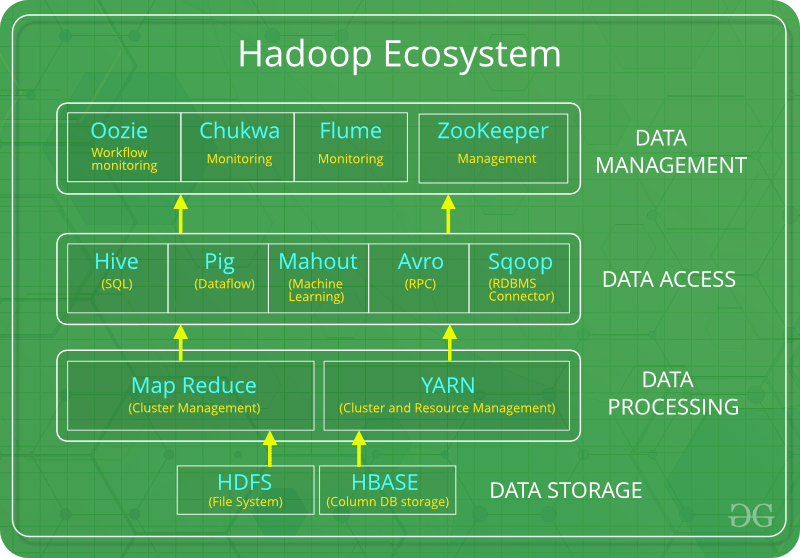

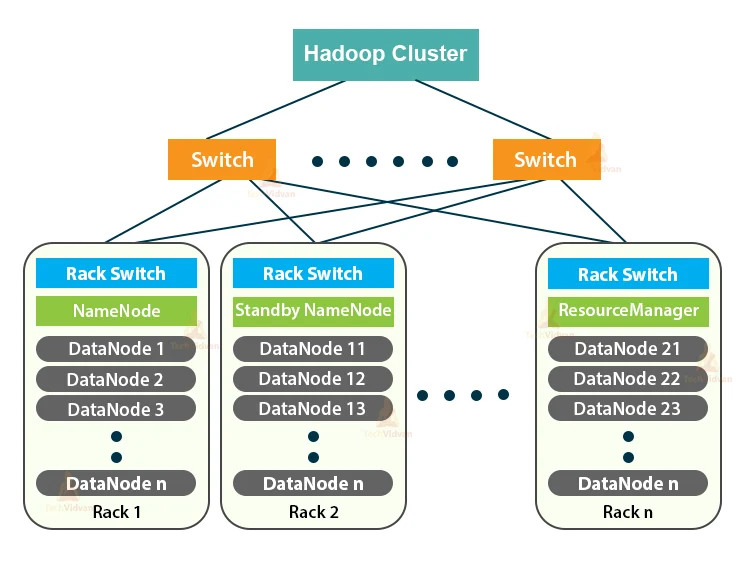

### https://medium.com/@aggarwalapurva89/hadoop-distributed-file-system-8d0d057a873c

## https://www.analyticsvidhya.com/blog/2022/04/an-overview-of-hdfs-namenodes-and-datanodes/

# Apache Hive 

## Overview
Apache Hive is a data warehousing and SQL-like query tool built on Hadoop, enabling data analysts to work with big data using familiar SQL-like syntax (HiveQL). It abstracts MapReduce complexity while providing powerful data processing capabilities.

## Key Features
- **SQL-like Language (HiveQL)**: Familiar syntax for data querying
- **Schema on Read**: Flexible schema definition at query time
- **Hadoop Integration**: Processing via MapReduce, Tez, or Spark
- **Data Organization**: Supports partitioning and bucketing
- **File Format Support**: Compatible with Text, ORC, Parquet, Avro
- **Extensibility**: Custom UDFs for complex computations
- **Enterprise Scale**: Handles petabyte-scale datasets

## Architecture Components

### 1. Interface Layer
- Command Line Interface (CLI)
- JDBC/ODBC drivers
- Web-based UI

### 2. Processing Layer
- **Driver**: Query parsing and execution control
- **Compiler**: Converts HiveQL to execution DAG
- **Optimizer**: Optimizes query execution plan
- **Executor**: Runs tasks on Hadoop cluster

### 3. Infrastructure Layer
- **Metastore**: Schema and metadata repository
- **Storage**: HDFS or compatible systems
- **Execution Engine**: MapReduce/Tez/Spark

## Data Organization

### Tables
```sql
-- Managed Table Example
CREATE TABLE employees (
    id INT,
    name STRING,
    age INT,
    department STRING
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE;
```

### Partitioning
```sql
-- Partitioned Table Example
CREATE TABLE sales (
    id INT,
    amount FLOAT
)
PARTITIONED BY (year INT, month INT)
STORED AS PARQUET;
```

### Bucketing
```sql
-- Bucketed Table Example
CREATE TABLE students (
    id INT,
    name STRING
)
CLUSTERED BY (id) INTO 4 BUCKETS
STORED AS ORC;
```

## Common Operations

### Data Loading
```sql
-- Load data into table
LOAD DATA INPATH '/path/to/employees.csv' 
INTO TABLE employees;
```

### Basic Queries
```sql
-- Aggregate Query Example
SELECT department, AVG(age) as avg_age
FROM employees
GROUP BY department;
```

## Advantages
- SQL familiarity for analysts
- Scalable data processing
- Custom function support
- Hadoop ecosystem integration
- Flexible data organization

## Limitations
- Higher latency (batch-oriented)
- Complex join performance
- Limited update capabilities
- Hadoop dependency
- Not suitable for real-time queries

## Use Cases
1. **Data Analysis**
   - Log processing
   - User behavior analysis
   - Business intelligence

2. **Data Processing**
   - ETL workflows
   - Data transformation
   - Batch processing

3. **Enterprise Applications**
   - Data warehousing
   - Report generation
   - Historical analysis

## Best Practices
1. **Performance Optimization**
   - Use appropriate file formats (ORC/Parquet)
   - Implement partitioning strategy
   - Optimize join operations

2. **Data Organization**
   - Plan partition columns carefully
   - Use bucketing for large datasets
   - Implement efficient storage formats

3. **Query Design**
   - Write optimized HiveQL
   - Use appropriate indexing
   - Leverage partitioning in queries

# Apache HBase Technical Guide

## Overview
Apache HBase is a distributed, non-relational database built on Hadoop, designed for low-latency random access to large datasets. Based on Google's Bigtable, it excels at handling sparse, column-oriented data at scale.

## Key Features
- **Column-Oriented Storage**: Optimized for analytical queries
- **Horizontal Scalability**: Easy node addition for growth
- **Low Latency**: Millisecond-level read/write operations
- **Hadoop Integration**: Native HDFS storage support
- **Flexible Schema**: Accommodates sparse datasets
- **Strong Consistency**: Unlike many NoSQL solutions
- **Massive Scale**: Supports billions of rows/millions of columns

## Architecture Components

### 1. Master-Slave Framework
- **HBase Master**
  - Region server management
  - Metadata operations handling
  - Region load balancing
  
- **Region Servers**
  - Data storage and management
  - Read/write request handling
  - Region maintenance

- **Supporting Infrastructure**
  - HDFS: Distributed storage backend
  - ZooKeeper: Cluster coordination and HA

## Data Model

### Hierarchical Structure
1. **Tables**
   - Similar to relational databases
   - No fixed schema requirement

2. **Rows**
   - Unique row key identification
   - Dynamic column support

3. **Column Families**
   - Predefined column groupings
   - Example: 'personal_info', 'address_details'

4. **Columns**
   - Dynamic within families
   - Flexible per-row structure

5. **Cell Versioning**
   - Multiple versions per cell
   - Timestamp-based versioning

## Basic Operations

### Table Management
```bash
# Create table
create 'students', 'personal_info', 'grades'

# Disable table
disable 'students'

# Drop table
drop 'students'
```

### Data Operations
```bash
# Insert data
put 'students', '1', 'personal_info:name', 'John Doe'
put 'students', '1', 'grades:math', 'A'

# Read data
get 'students', '1'

# Scan table
scan 'students'

# Delete data
delete 'students', '1', 'grades:math'
```

## Advantages
- High-throughput write operations
- Fast random access capabilities
- Horizontal scalability
- Built-in fault tolerance
- Hadoop ecosystem integration

## Limitations
1. **Technical Complexity**
   - Steep learning curve
   - Complex setup and maintenance

2. **Performance Considerations**
   - Not ideal for sub-millisecond latency
   - Requires careful optimization

3. **Dependencies**
   - HDFS requirement
   - ZooKeeper dependency
   - Hadoop ecosystem complexity

4. **Query Limitations**
   - No native SQL support
   - API-based querying

## Use Cases

### 1. Log Analysis
- Server log storage
- Real-time log processing
- Historical log analysis

### 2. Real-Time Systems
- Time-series data handling
- IoT sensor data storage
- Financial transaction tracking

### 3. Content Systems
- Dynamic website backends
- Content management systems
- Media storage platforms

### 4. Analytics Platforms
- Search engine indexing
- Recommendation engines
- User behavior analysis

## Best Practices

### 1. Design Considerations
- Plan row keys carefully
- Optimize column family structure
- Consider data access patterns

### 2. Performance Optimization
- Balance region server loads
- Monitor cluster health
- Implement proper caching

### 3. Maintenance
- Regular compaction scheduling
- Backup strategy implementation
- Monitoring and alerting setup

# Apache Flume Comprehensive Guide

## Overview
Apache Flume is a distributed, reliable data ingestion service designed for collecting, aggregating, and transporting large volumes of streaming data into centralized data stores. Primary use is in big data analytics pipelines.

## Core Architecture

### Main Components
1. **Source**
   - Ingests data into Flume
   - Types:
     - Spooling Directory
     - Netcat
     - HTTP
     - Syslog
     - Custom Sources

2. **Channel**
   - Buffers data between source and sink
   - Types:
     - Memory Channel (high speed)
     - File Channel (durable)
     - Kafka Channel (scalable)
     - JDBC Channel

3. **Sink**
   - Delivers data to destination
   - Types:
     - HDFS Sink
     - HBase Sink
     - Elasticsearch Sink
     - Custom Sinks

4. **Agent**
   - JVM process containing Source, Channel, and Sink
   - Manages data flow and component lifecycle

## Configuration Examples

### Basic HDFS Configuration
```properties
# Agent components
agent1.sources = source1
agent1.channels = channel1
agent1.sinks = sink1

# Source config
agent1.sources.source1.type = spooldir
agent1.sources.source1.spoolDir = /path/to/logs

# Channel config
agent1.channels.channel1.type = memory
agent1.channels.channel1.capacity = 1000
agent1.channels.channel1.transactionCapacity = 100

# Sink config
agent1.sinks.sink1.type = hdfs
agent1.sinks.sink1.hdfs.path = hdfs://namenode:8020/flume/logs
agent1.sinks.sink1.hdfs.fileType = DataStream

# Bindings
agent1.sources.source1.channels = channel1
agent1.sinks.sink1.channel = channel1
```

### Multi-Agent Configuration
```properties
# First agent
agent1.sources = source1
agent1.channels = channel1
agent1.sinks = sink1

# Second agent
agent2.sources = source2
agent2.channels = channel2
agent2.sinks = sink2

# Avro sink to connect agents
agent1.sinks.sink1.type = avro
agent1.sinks.sink1.hostname = second-agent-host
agent1.sinks.sink1.port = 4545
```

## Key Features

### 1. Reliability Mechanisms
- Transaction-based operation
- Delivery guarantees:
  - At-most-once
  - At-least-once
  - Exactly-once (with proper configuration)

### 2. Scalability Options
- Horizontal scaling through multiple agents
- Load balancing across channels
- Failover support

### 3. Data Flow Patterns
- Fan-out (one source, multiple channels)
- Fan-in (multiple sources, one channel)
- Multiplexing
- Load balancing

## Use Cases

### 1. Log Aggregation
```properties
# Web server log collection
agent.sources.weblog.type = exec
agent.sources.weblog.command = tail -F /var/log/nginx/access.log
agent.sources.weblog.channels = memChannel
```

### 2. Real-Time Streaming
```properties
# Social media stream ingestion
agent.sources.twitter.type = org.apache.flume.source.twitter.TwitterSource
agent.sources.twitter.channels = kafkaChannel
agent.sources.twitter.consumerKey = [KEY]
agent.sources.twitter.consumerSecret = [SECRET]
```

### 3. IoT Data Collection
```properties
# Sensor data ingestion
agent.sources.sensors.type = http
agent.sources.sensors.port = 5140
agent.sources.sensors.handler = org.apache.flume.source.http.JSONHandler
```

## Best Practices

### 1. Performance Optimization
- Use memory channel for speed
- Configure appropriate batch sizes
- Monitor channel capacity
- Balance between throughput and reliability

### 2. Reliability Configuration
- Use file channel for critical data
- Configure proper timeout values
- Implement backup channels
- Monitor transaction rates

### 3. Monitoring Setup
- JMX metrics monitoring
- Channel capacity tracking
- Source/Sink performance metrics
- Error rate monitoring

## Advantages
1. Flexible deployment options
2. Built-in reliability mechanisms
3. Extensive customization options
4. High-throughput capability
5. Hadoop ecosystem integration

## Limitations
1. Limited transformation capabilities
2. Primary focus on log/event data
3. Hadoop ecosystem dependency
4. Resource intensive for large setups

## Troubleshooting Guide

### Common Issues
1. **Channel Overflow**
   - Increase channel capacity
   - Adjust batch sizes
   - Monitor backpressure

2. **Memory Issues**
   - Configure JVM parameters
   - Monitor garbage collection
   - Adjust buffer sizes

3. **Data Loss**
   - Check delivery guarantees
   - Verify channel configuration
   - Monitor sink performance

# Apache Mahout Technical Guide

## Overview
Apache Mahout is an open-source machine learning library built on Hadoop, designed for scalable, distributed machine learning algorithms. It specializes in handling large-scale data processing through parallel computing frameworks.

## Core Features
- Scalable machine learning algorithms
- Hadoop/Spark integration
- Distributed processing support
- Sparse data handling
- Extensible architecture
- Comprehensive ML toolkit

## Supported Algorithms

### 1. Classification
- **Naive Bayes**
  - Text classification
  - Spam detection
  - Sentiment analysis

- **Logistic Regression**
  - Binary classification
  - Probability estimation
  - Risk assessment

### 2. Clustering
- **K-Means**
  - Customer segmentation
  - Pattern recognition
  - Data grouping

- **Latent Dirichlet Allocation (LDA)**
  - Topic modeling
  - Document clustering
  - Content categorization

### 3. Collaborative Filtering
- **User-Based**
  - Personal recommendations
  - Preference prediction
  - Behavioral analysis

- **Item-Based**
  - Product recommendations
  - Content similarity
  - Cross-selling

### 4. Dimensionality Reduction
- **Principal Component Analysis (PCA)**
  - Feature reduction
  - Data compression
  - Pattern identification

## Implementation Examples

### 1. K-Means Clustering
```bash
# Prepare and run clustering
mahout clusterdist \
  --input /data/input_dir \
  --output /data/output_dir \
  --k 3 \
  --clustering

# Evaluate clusters
mahout clusterdump \
  --input /data/output_dir \
  --output cluster_dump.txt \
  --pointsDir /data/points
```

### 2. Recommendation System
```bash
# Build recommender
mahout recommenditembased \
  --input /data/user_preferences \
  --output /data/recommendations \
  --numRecommendations 10 \
  --similarityClassname SIMILARITY_COSINE

# Generate recommendations
mahout evaluateFactorization \
  --input /data/recommendations \
  --output /data/evaluation \
  --userFeatures /data/userFeatures
```

## Architecture Components

### 1. Core Components
- Client Interface (CLI/API)
- Algorithm Implementation
- Data Processing Engine
- Storage Layer (HDFS)
- Output Handler

### 2. Processing Flow
1. Data Ingestion
2. Preprocessing
3. Algorithm Execution
4. Result Generation
5. Output Storage

## Use Cases

### 1. Recommender Systems
```java
// Initialize recommender
DataModel model = new FileDataModel(new File("ratings.csv"));
UserSimilarity similarity = new PearsonCorrelationSimilarity(model);
UserNeighborhood neighborhood = new ThresholdUserNeighborhood(0.1, similarity, model);
Recommender recommender = new GenericUserBasedRecommender(model, neighborhood, similarity);
```

### 2. Customer Segmentation
```java
// K-Means configuration
Configuration conf = new Configuration();
Path input = new Path("customers.seq");
Path output = new Path("clusters");
KMeansDriver.run(conf, input, output, new Path("cluster-centers"), 0.001, 20, true, 0.5, false);
```

## Best Practices

### 1. Performance Optimization
- Use appropriate data formats
- Configure memory allocation
- Optimize cluster settings
- Implement proper partitioning

### 2. Algorithm Selection
- Consider data size
- Evaluate sparsity
- Assess computational resources
- Match business requirements

### 3. Data Preparation
- Clean input data
- Handle missing values
- Normalize features
- Convert to proper format

## Advantages
1. **Scalability**
   - Handles massive datasets
   - Distributed processing
   - Horizontal scaling

2. **Integration**
   - Hadoop ecosystem
   - Spark compatibility
   - HDFS storage

3. **Flexibility**
   - Algorithm customization
   - Extension support
   - Multiple use cases

## Limitations
1. **Technical Complexity**
   - Complex setup
   - Steep learning curve
   - Java-centric

2. **Development Status**
   - Less active community
   - Limited algorithm selection
   - Slower updates

3. **Resource Requirements**
   - High computational needs
   - Memory intensive
   - Infrastructure dependent

## Troubleshooting Guide

### Common Issues
1. **Performance Problems**
   - Check data partitioning
   - Verify memory allocation
   - Monitor cluster health

2. **Algorithm Failures**
   - Validate input format
   - Check parameter settings
   - Review error logs

3. **Integration Issues**
   - Verify version compatibility
   - Check dependencies
   - Confirm environment setup



# Apache Oozie

Apache Oozie is a workflow scheduler system for managing and coordinating jobs in Hadoop. It allows users to define workflows comprising a series of actions (e.g., MapReduce jobs, Hive queries, Pig scripts) and manages the execution of these jobs in a defined sequence or based on triggers like time or data availability.

## Key Features of Oozie

### Workflow Management
* Supports defining workflows as Directed Acyclic Graphs (DAGs), where each node represents an action or task
* Manages dependencies between tasks, ensuring they are executed in the correct order

### Coordination
* Can schedule jobs based on time or event triggers (e.g., the arrival of new data in HDFS)
* Example: Run a job every day at 2 AM or when new data arrives in a directory

### Extensibility
* Supports custom actions and extensions, enabling integration with various Hadoop components like MapReduce, Hive, Pig, and Spark

### Retry Mechanism
* Handles task failures by retrying them based on user-defined policies

### Scalability
* Built to handle complex workflows with numerous jobs across large Hadoop clusters

## Architecture of Oozie

### 1. Workflow Engine
* Executes workflows written in XML, where tasks are defined and linked
* Supports conditional execution and branching

### 2. Coordinator Engine
* Manages workflows based on triggers, such as time schedules or data availability

### 3. Bundle Engine
* Groups multiple coordinators and workflows into a single logical unit for management and execution

## Workflow Example

Imagine a data pipeline involving:
1. Fetching data from an external source (using Sqoop)
2. Running a data cleansing script (using MapReduce or Spark)
3. Loading data into Hive tables
4. Generating a report using a Pig script

### Oozie Workflow Example

```xml
<workflow-app xmlns="uri:oozie:workflow:0.5" name="example-wf">
    <start to="fetch-data"/>
    
    <action name="fetch-data">
        <java>
            <job-tracker>${jobTracker}</job-tracker>
            <name-node>${nameNode}</name-node>
            <main-class>com.example.FetchData</main-class>
        </java>
        <ok to="process-data"/>
        <error to="fail"/>
    </action>
    
    <action name="process-data">
        <map-reduce>
            <job-tracker>${jobTracker}</job-tracker>
            <name-node>${nameNode}</name-node>
            <configuration>
                <property>
                    <name>mapred.input.dir</name>
                    <value>${inputDir}</value>
                </property>
                <property>
                    <name>mapred.output.dir</name>
                    <value>${outputDir}</value>
                </property>
            </configuration>
        </map-reduce>
        <ok to="generate-report"/>
        <error to="fail"/>
    </action>
    
    <action name="generate-report">
        <pig>
            <job-tracker>${jobTracker}</job-tracker>
            <name-node>${nameNode}</name-node>
            <script>${reportScript}</script>
        </pig>
        <ok to="end"/>
        <error to="fail"/>
    </action>
    
    <kill name="fail">
        <message>Workflow failed, error message[${wf:errorMessage(wf:lastErrorNode())}]</message>
    </kill>
    
    <end name="end"/>
</workflow-app>
```

### Oozie Coordination Example

```xml
<coordinator-app xmlns="uri:oozie:coordinator:0.4" name="example-coordinator">
    <controls>
        <timeout>1440</timeout>
        <concurrency>1</concurrency>
        <execution>FIFO</execution>
    </controls>
    <datasets>
        <dataset name="input-data" frequency="daily" initial-instance="2024-01-01T00:00Z" timezone="UTC">
            <uri-template>/data/input/${YEAR}/${MONTH}/${DAY}</uri-template>
        </dataset>
    </datasets>
    <action>
        <workflow>
            <app-path>${wfAppPath}</app-path>
            <configuration>
                <property>
                    <name>jobTracker</name>
                    <value>${jobTracker}</value>
                </property>
                <property>
                    <name>nameNode</name>
                    <value>${nameNode}</value>
                </property>
            </configuration>
        </workflow>
    </action>
</coordinator-app>
```

## Advantages of Oozie

### Integration
* Works seamlessly with Hadoop tools like Hive, Pig, and Spark

### Automation
* Automates complex workflows and reduces manual intervention

### Efficiency
* Handles job dependencies and retries, minimizing failures

### Customizability
* Supports user-defined actions and configurations

## Limitations of Oozie

### Complex Configuration
* Writing XML workflows can be error-prone and challenging

### Limited UI
* The UI for managing workflows is not as advanced as some modern tools

### Tight Coupling with Hadoop
* Primarily designed for the Hadoop ecosystem, limiting its use in other environments

# Apache Sqoop

Apache Sqoop (SQL to Hadoop and Hadoop to SQL) is a tool designed to efficiently transfer data between Hadoop ecosystems (like HDFS, Hive, or HBase) and relational databases (like MySQL, PostgreSQL, Oracle, etc.). It acts as a bridge, enabling data ingestion and export for big data workflows.

## Key Features of Sqoop

### Data Import
* Sqoop can pull data from relational databases into Hadoop (HDFS), Hive, or HBase

### Data Export
* Exports processed data from Hadoop back to relational databases

### Parallel Data Transfer
* Utilizes MapReduce to enable parallel data import/export, ensuring high performance

### Data Transformation
* Includes support for running custom queries to transform data during the transfer process

### Integration
* Works seamlessly with popular databases and Hadoop components

### Incremental Loads
* Supports importing only new or modified rows using incremental mode

### Support for Compression
* Data transferred into Hadoop can be stored in compressed formats to save space

## How Sqoop Works

### 1. Importing Data
Sqoop pulls data from an RDBMS table and writes it into Hadoop in formats like text, Avro, or Parquet.

Command Example:
```bash
sqoop import \
--connect jdbc:mysql://localhost/database_name \
--username root \
--password secret \
--table employees \
--target-dir /data/employees
```

Key Parameters:
* `--connect`: JDBC connection string
* `--table`: Specifies the source database table
* `--target-dir`: HDFS directory where data will be stored

### 2. Exporting Data
Sqoop exports data from HDFS into a relational database.

```bash
sqoop export \
--connect jdbc:mysql://localhost/database_name \
--username root \
--password secret \
--table employees_processed \
--export-dir /processed/employees
```

Key Parameters:
* `--table`: Specifies the target database table
* `--export-dir`: HDFS directory containing data to export

### 3. Incremental Imports
Sqoop supports append mode and lastmodified mode for importing only new or updated rows.

```bash
sqoop import \
--connect jdbc:mysql://localhost/database_name \
--username root \
--password secret \
--table employees \
--target-dir /data/employees \
--incremental append \
--check-column id \
--last-value 100
```

Key Parameters:
* `--incremental`: Specifies the mode (append or lastmodified)
* `--check-column`: Column to check for new data
* `--last-value`: Last imported value for the column

## Sqoop Architecture

### Command-Line Interface
* Users interact with Sqoop using CLI commands to specify data source, target, and configurations

### Connectors
* Sqoop uses database-specific connectors (e.g., MySQL, Oracle, PostgreSQL) to connect to the source or target

### MapReduce Framework
* Transfers data using MapReduce for parallel processing and fault tolerance

### Hadoop Ecosystem
* Imported data can be stored in HDFS, Hive, or HBase for further analysis

## Advantages of Sqoop

### Efficiency
* Leverages parallelism via MapReduce for fast data transfers

### Ease of Use
* Simple CLI commands for complex tasks like incremental imports

### Cost-Effective
* Open-source tool with robust features

### Integration
* Supports a wide range of databases and big data tools

## Limitations of Sqoop

### Batch Processing
* Not suitable for real-time data transfers

### Dependency on MapReduce
* Performance may be suboptimal in modern big data environments relying on Spark

### Complexity for Large Schemas
* Handling tables with complex schemas or large volumes of data requires careful tuning

## Real-World Use Cases

### Data Ingestion
* Import customer data from an enterprise database into Hadoop for analysis

### Data Export
* Export transformed or aggregated data from Hadoop to a database for reporting

### Incremental Updates
* Synchronize a database with Hadoop by importing only new or modified data

### ETL Pipelines
* Use Sqoop to extract data, transform it in Hadoop, and load it back into a database